# Task 1: Simulation and Sensitivity Analysis of Chaotic Systems

This notebook implements Parts A, B and C of the assignment: discrete chaotic maps, continuous chaotic/hyperchaotic flows, and the sensitivity analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os

FIGDIR = "figs"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(fig, name):
    fig.savefig(os.path.join(FIGDIR, name), dpi=150, bbox_inches="tight")
    print("saved", name)


## Part A -- Discrete Chaotic Systems
### A.2 Logistic Map
$x_{n+1} = r\,x_n(1-x_n)$

saved A2_logistic_timeseries.png


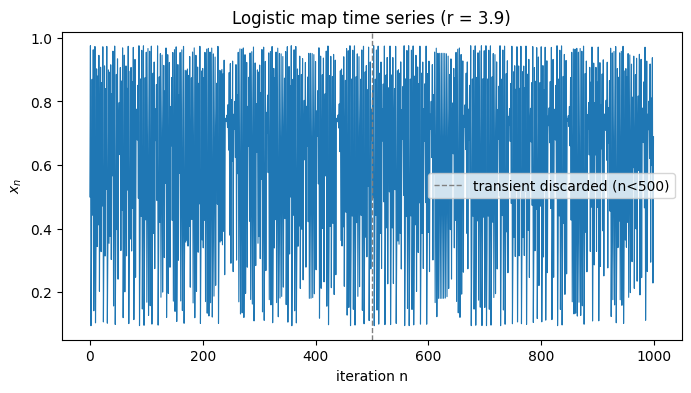

In [2]:
def logistic_iterate(r, x0=0.5, n_iter=1000, transient=500):
    x = np.empty(n_iter)
    x[0] = x0
    for n in range(1, n_iter):
        x[n] = r * x[n-1] * (1 - x[n-1])
    return x[transient:], x

r_demo = 3.9
retained, full_series = logistic_iterate(r_demo, x0=0.5, n_iter=1000, transient=500)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(full_series)), full_series, lw=0.8, color="#1f77b4")
ax.axvline(500, color="gray", ls="--", lw=1, label="transient discarded (n<500)")
ax.set_xlabel("iteration n"); ax.set_ylabel(r"$x_n$")
ax.set_title(f"Logistic map time series (r = {r_demo})")
ax.legend()
savefig(fig, "A2_logistic_timeseries.png")
plt.show()


At r = 3.9 the values of xn just keep jumping around inside [0, 1] and never settle into a repeating
pattern. There’s no period I could spot by eye, which is basically what chaos looks like for a 1D
map like this one.
1.2 A.3 H´enon

### A.4 Logistic Map -- Bifurcation Diagram

saved A4_logistic_bifurcation.png


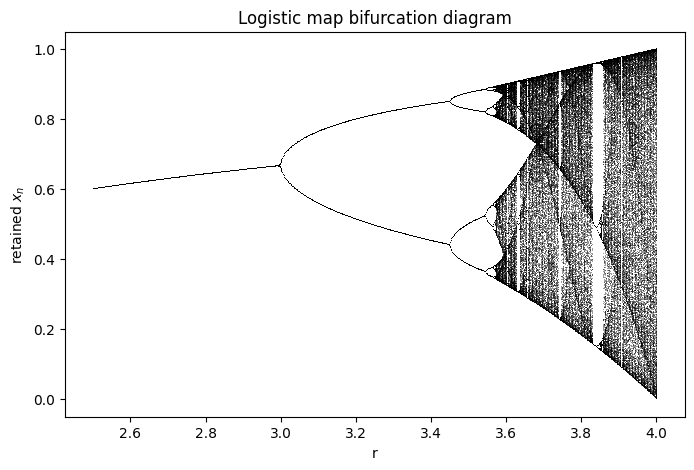

In [3]:
r_vals = np.arange(2.5, 4.0 + 1e-9, 0.002)
n_iter, transient = 1000, 500
r_plot, x_plot = [], []
for r in r_vals:
    x = 0.5
    for n in range(n_iter):
        x = r * x * (1 - x)
        if n >= transient:
            r_plot.append(r); x_plot.append(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r_plot, x_plot, ",", color="black", alpha=0.4, markersize=0.3)
ax.set_xlabel("r"); ax.set_ylabel(r"retained $x_n$")
ax.set_title("Logistic map bifurcation diagram")
savefig(fig, "A4_logistic_bifurcation.png")
plt.show()


For the logistic map, up to r = 3 the system just settles on one value (a fixed point). After that
it starts splitting into 2, then 4, then 8 branches and so on, this is the period-doubling everyone
talks about, and it happens faster and faster until around r ≈ 3.57 where it turns into chaos (the
4
solid black region). There are also thin white gaps inside the chaotic part, those are the periodic
windows where the system briefly goes back to a simple repeating behavior before turning chaotic
again (you can see one clearly around r ≈ 3.83).

### A.3 Hénon Map
$x_{n+1} = 1 - a x_n^2 + y_n,\qquad y_{n+1} = b x_n$

saved A3_henon_attractor.png


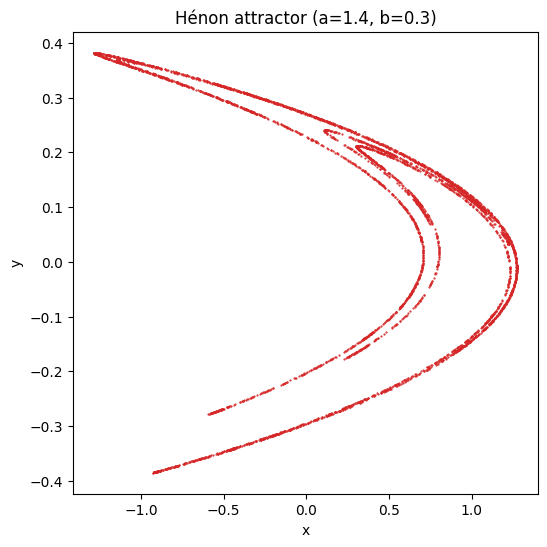

In [4]:
def henon_iterate(a, b, x0=0.0, y0=0.0, n_iter=5000, transient=500):
    x = np.empty(n_iter); y = np.empty(n_iter)
    x[0], y[0] = x0, y0
    for n in range(1, n_iter):
        x[n] = 1 - a * x[n-1]**2 + y[n-1]
        y[n] = b * x[n-1]
    return x[transient:], y[transient:]

a_demo, b_demo = 1.4, 0.3
hx, hy = henon_iterate(a_demo, b_demo, n_iter=5000, transient=500)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(hx, hy, s=0.3, color="#d62728")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"Hénon attractor (a={a_demo}, b={b_demo})")
savefig(fig, "A3_henon_attractor.png")
plt.show()


### A.4 Hénon Map -- Bifurcation Diagram (sweeping $a$, $b$ fixed)

saved A4_henon_bifurcation.png


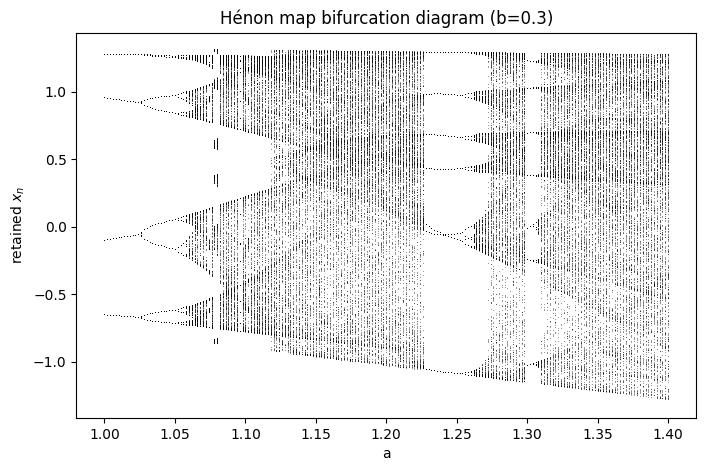

In [5]:
a_vals = np.arange(1.0, 1.4 + 1e-9, 0.002)
b_fixed = 0.3
n_iter, transient = 1000, 500
a_plot, x_plot2 = [], []
for a in a_vals:
    x, y = 0.0, 0.0
    for n in range(n_iter):
        x, y = 1 - a * x**2 + y, b_fixed * x
        if n >= transient:
            a_plot.append(a); x_plot2.append(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(a_plot, x_plot2, ",", color="black", alpha=0.4, markersize=0.3)
ax.set_xlabel("a"); ax.set_ylabel(r"retained $x_n$")
ax.set_title(f"Hénon map bifurcation diagram (b={b_fixed})")
savefig(fig, "A4_henon_bifurcation.png")
plt.show()


this is the same as that for logistic map but for 2D: as a increases the fixed point becomes unstable, it splits into more branches, and eventually becomes chaotic with some narrow clean windows in between. So both  maps go through basically the same route to chaos, period doubling, even though one is 1D and the other is 2D.

## Part B -- Continuous Chaotic Systems

Right-hand sides for all four flows, plus a shared RK45 integration helper and a plotting helper that produces a 3-D phase portrait and a stacked time-series figure.

In [6]:
def lorenz_rhs(t, s, sigma, rho, beta):
    x, y, z = s
    return [sigma*(y-x), x*(rho-z) - y, x*y - beta*z]

def rossler_rhs(t, s, a, b, c):
    x, y, z = s
    return [-y - z, x + a*y, b + z*(x - c)]

def chen_rhs(t, s, a, b, c):
    x, y, z = s
    return [a*(y-x), (c-a)*x - x*z + c*y, x*y - b*z]

def hyperchaotic_rossler_rhs(t, s, a, b, c, d):
    x, y, z, w = s
    return [-y - z, x + a*y + w, b + x*z, -c*z + d*w]

def integrate(rhs, ic, t_span, dt, args, method="RK45", rtol=1e-9, atol=1e-9):
    t_eval = np.arange(t_span[0], t_span[1] + dt/2, dt)
    sol = solve_ivp(rhs, t_span, ic, method=method, t_eval=t_eval, args=args,
                     max_step=dt, rtol=rtol, atol=atol)
    return sol.t, sol.y

def plot_3d_and_timeseries(t, Y, labels, title, fname_prefix):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.plot(Y[0], Y[1], Y[2], lw=0.5, color="#2ca02c")
    ax.set_xlabel(labels[0]); ax.set_ylabel(labels[1]); ax.set_zlabel(labels[2])
    ax.set_title(f"{title} -- phase space")
    savefig(fig, f"{fname_prefix}_phase3d.png")
    plt.show()

    n = Y.shape[0]
    fig, axs = plt.subplots(n, 1, figsize=(9, 2*n), sharex=True)
    if n == 1: axs = [axs]
    for i in range(n):
        axs[i].plot(t, Y[i], lw=0.6, color="#1f77b4")
        axs[i].set_ylabel(labels[i])
    axs[-1].set_xlabel("t")
    fig.suptitle(f"{title} -- time series")
    savefig(fig, f"{fname_prefix}_timeseries.png")
    plt.show()


### B.2 Lorenz System
$\dot{x}=\sigma(y-x),\quad \dot{y}=x(\rho-z)-y,\quad \dot{z}=xy-\beta z$

Settings: $\sigma=10,\ \rho=28,\ \beta=8/3$; IC $(1,1,1)$; $dt=0.01$; $T=50$; RK45.

saved B2_lorenz_phase3d.png


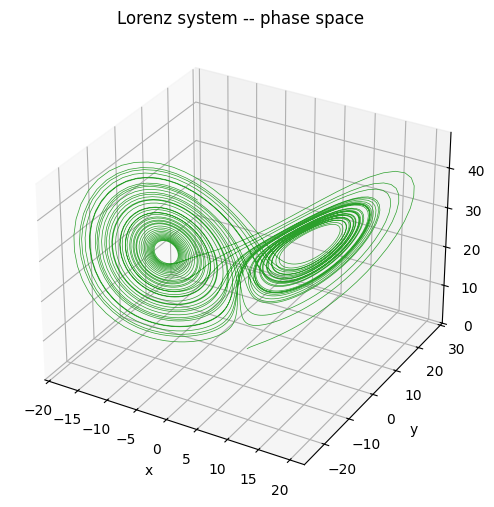

saved B2_lorenz_timeseries.png


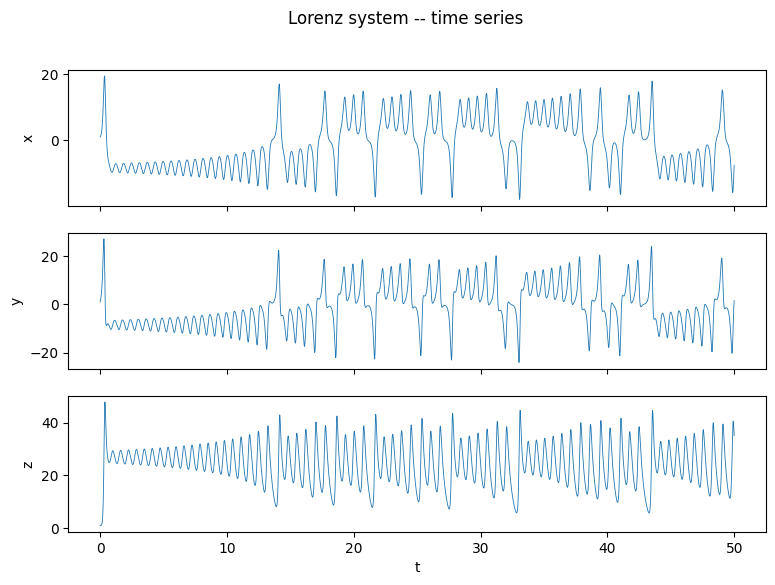

In [7]:
lorenz_params = dict(sigma=10.0, rho=28.0, beta=8/3)
t_l, Y_l = integrate(lorenz_rhs, [1, 1, 1], (0, 50), 0.01,
                      args=(lorenz_params["sigma"], lorenz_params["rho"], lorenz_params["beta"]))
plot_3d_and_timeseries(t_l, Y_l, ["x", "y", "z"], "Lorenz system", "B2_lorenz")


look at the time series graphs. This is the famous butterfly shape. The trajectory spirals around one ”wing” for a while, then randomly jumps to the other wing, then back, and it never really repeats the same loop twice. It stays inside the same general region the whole time though, it doesn’t blow up.

### B.3 Rössler System
$\dot{x}=-y-z,\quad \dot{y}=x+ay,\quad \dot{z}=b+z(x-c)$

Settings: $a=0.2,\ b=0.2,\ c=5.7$; IC $(0,0,0)$; $dt=0.01$; $T=200$; RK45.

saved B3_rossler_phase3d.png


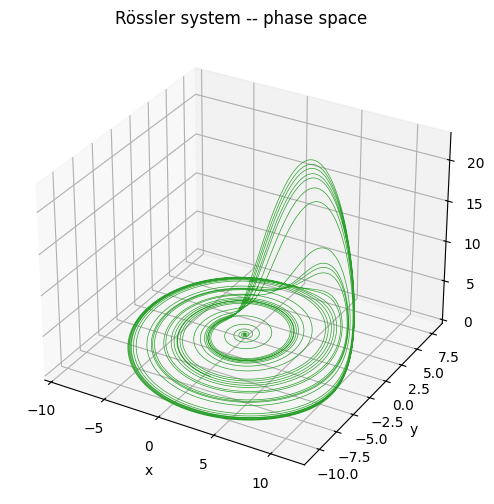

saved B3_rossler_timeseries.png


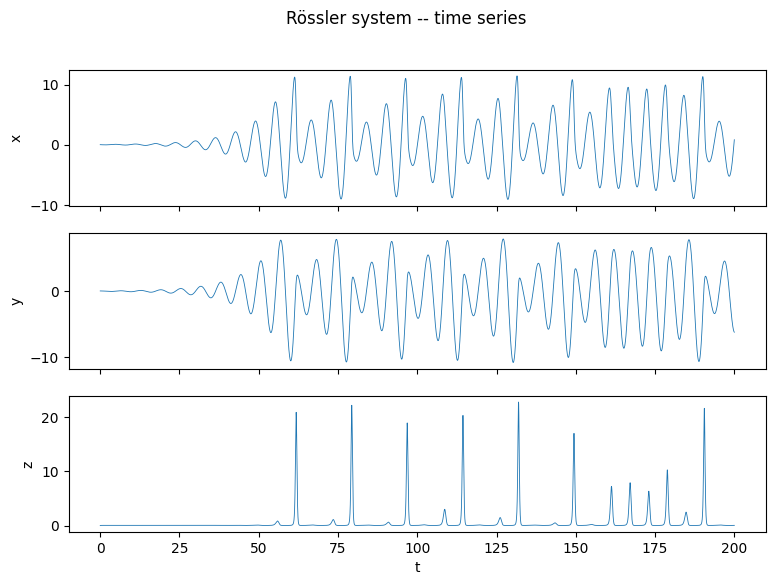

In [8]:
rossler_params = dict(a=0.2, b=0.2, c=5.7)
t_r, Y_r = integrate(rossler_rhs, [0, 0, 0], (0, 200), 0.01,
                      args=(rossler_params["a"], rossler_params["b"], rossler_params["c"]))
plot_3d_and_timeseries(t_r, Y_r, ["x", "y", "z"], "Rössler system", "B3_rossler")


The Rössler attractor looks a lot simpler than Lorenz, it’s basically one spiral that loops around flatly and every so often shoots up and folds back down near the center. That’s why it’s usually called a single-scroll attractor there’s only one ”loop shape” instead of two wings.

### B.4 Chen System
$\dot{x}=a(y-x),\quad \dot{y}=(c-a)x-xz+cy,\quad \dot{z}=xy-bz$

Settings: $a=35,\ b=3,\ c=28$; IC $(-0.1,0.5,-0.6)$; $dt=0.002$ (stiffer than Lorenz); $T=50$; RK45.

saved B4_chen_phase3d.png


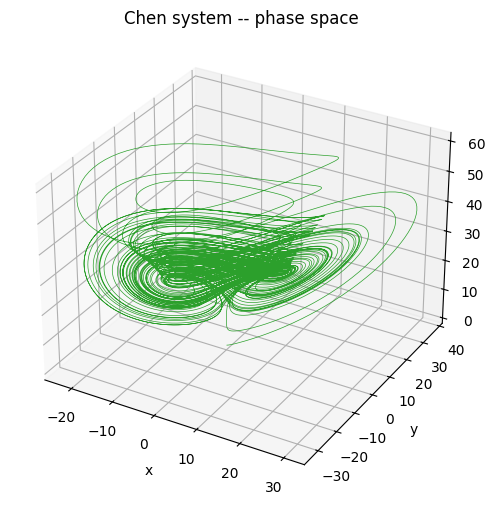

saved B4_chen_timeseries.png


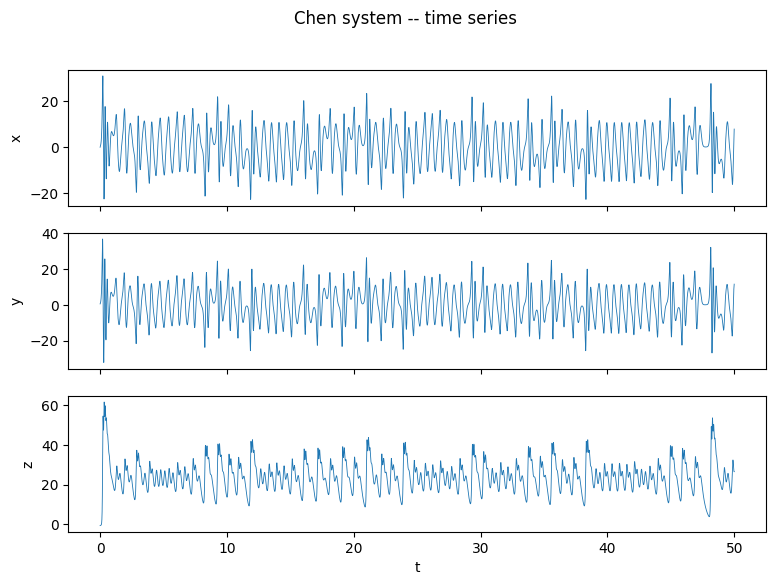

In [9]:
chen_params = dict(a=35.0, b=3.0, c=28.0)
t_c, Y_c = integrate(chen_rhs, [-0.1, 0.5, -0.6], (0, 50), 0.002,
                      args=(chen_params["a"], chen_params["b"], chen_params["c"]))
plot_3d_and_timeseries(t_c, Y_c, ["x", "y", "z"], "Chen system", "B4_chen")


Chen also has two wings like Lorenz (double-scroll), but they’re squeezed closer together and the system switchs between them faster. I had to use a smaller dt here because with the same dt as Lorenz the simulation started blowing up, Chen’s equations are just more sensitive numerically (stiffer) because of the larger parameter values.

### B.5 Hyperchaotic Rössler System
$\dot{x}=-y-z,\quad \dot{y}=x+ay+w,\quad \dot{z}=b+xz,\quad \dot{w}=-cz+dw$

Settings: $a=0.25,\ b=3,\ c=0.5,\ d=0.05$; IC $(-10,-6,0,10)$; $dt=0.01$; $T=250$; RK45. The 4-D state cannot be drawn directly, so 2-D/3-D projections are used.

saved B5_hyperrossler_projections2d.png


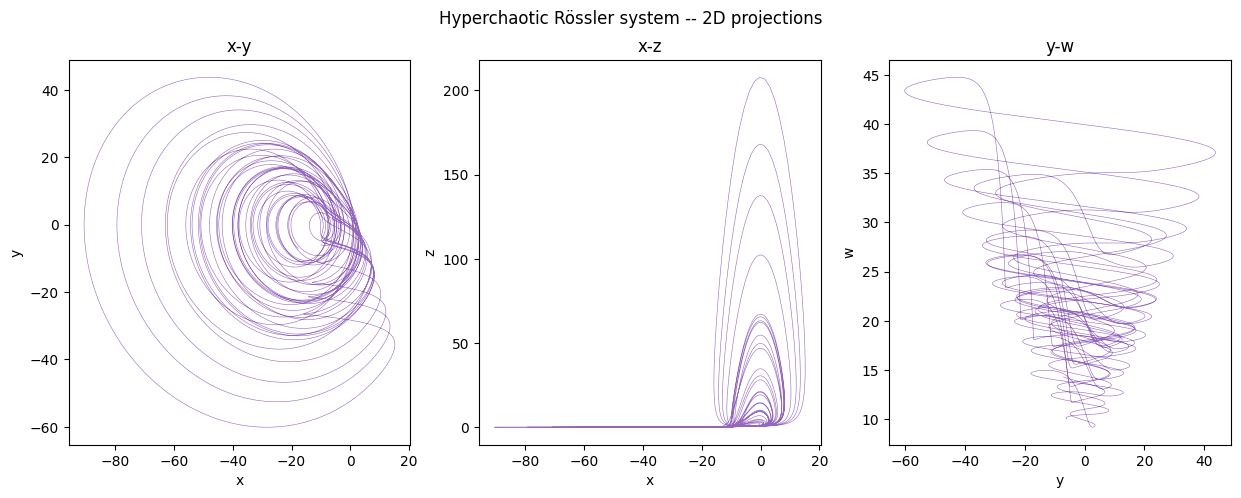

saved B5_hyperrossler_phase3d.png


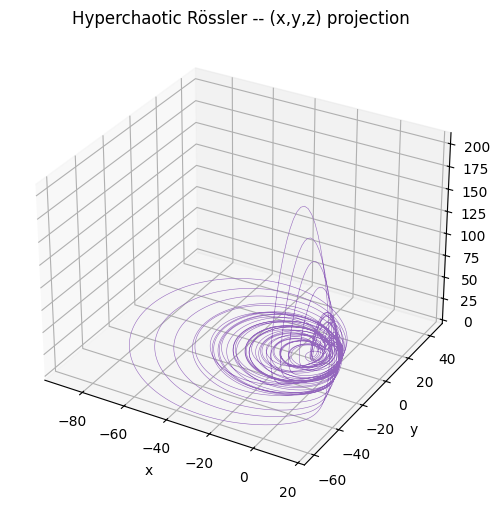

saved B5_hyperrossler_timeseries.png


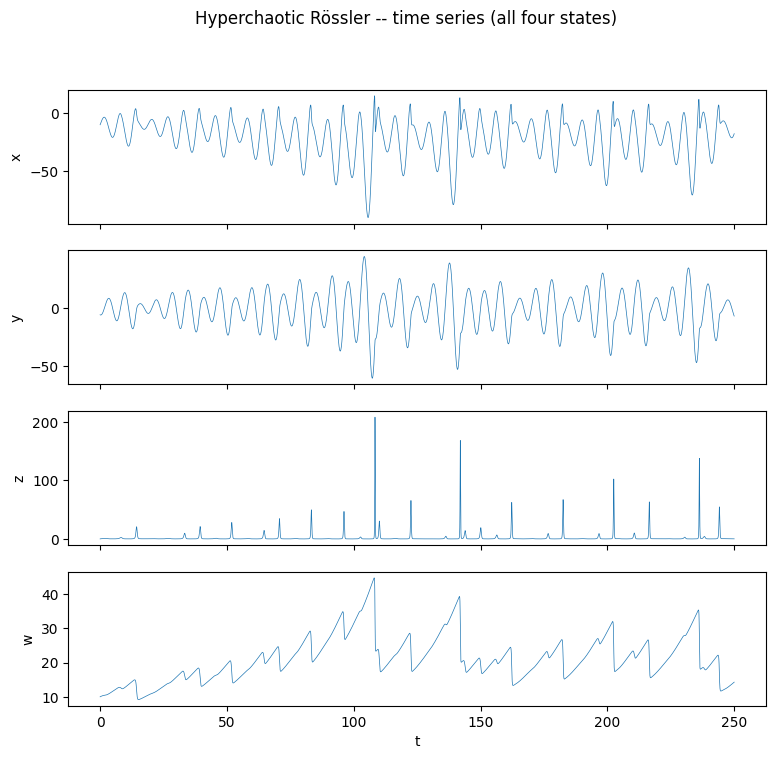

In [10]:
hr_params = dict(a=0.25, b=3.0, c=0.5, d=0.05)
t_h, Y_h = integrate(hyperchaotic_rossler_rhs, [-10, -6, 0, 10], (0, 250), 0.01,
                      args=(hr_params["a"], hr_params["b"], hr_params["c"], hr_params["d"]))
x_h, y_h, z_h, w_h = Y_h

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].plot(x_h, y_h, lw=0.4, color="#9467bd"); axs[0].set_xlabel("x"); axs[0].set_ylabel("y"); axs[0].set_title("x-y")
axs[1].plot(x_h, z_h, lw=0.4, color="#9467bd"); axs[1].set_xlabel("x"); axs[1].set_ylabel("z"); axs[1].set_title("x-z")
axs[2].plot(y_h, w_h, lw=0.4, color="#9467bd"); axs[2].set_xlabel("y"); axs[2].set_ylabel("w"); axs[2].set_title("y-w")
fig.suptitle("Hyperchaotic Rössler system -- 2D projections")
savefig(fig, "B5_hyperrossler_projections2d.png")
plt.show()

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x_h, y_h, z_h, lw=0.4, color="#9467bd")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Hyperchaotic Rössler -- (x,y,z) projection")
savefig(fig, "B5_hyperrossler_phase3d.png")
plt.show()

fig, axs = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for i, lbl in enumerate(["x", "y", "z", "w"]):
    axs[i].plot(t_h, Y_h[i], lw=0.5, color="#1f77b4")
    axs[i].set_ylabel(lbl)
axs[-1].set_xlabel("t")
fig.suptitle("Hyperchaotic Rössler -- time series (all four states)")
savefig(fig, "B5_hyperrossler_timeseries.png")
plt.show()


Compared to the regular Rössler attractor, this one looks a lot messier, the loops are more spread out and don’t stay the same size like before. I think that makes sense given the definition: since there are now two directions where nearby trajectories are pulling apart instead of one, the whole thing should look less "clean" than the single-scroll R¨ossler.

## Part C -- Sensitivity Analysis
### C.1 Parameter Sweep of the Lorenz System ($\rho$)

Sweep $\rho \in [0,30]$ with $\sigma=10,\ \beta=8/3$ fixed; same IC/dt/solver/length as B.2; discard $t<20$; record local maxima of $z(t)$.

saved C1_lorenz_rho_sweep.png


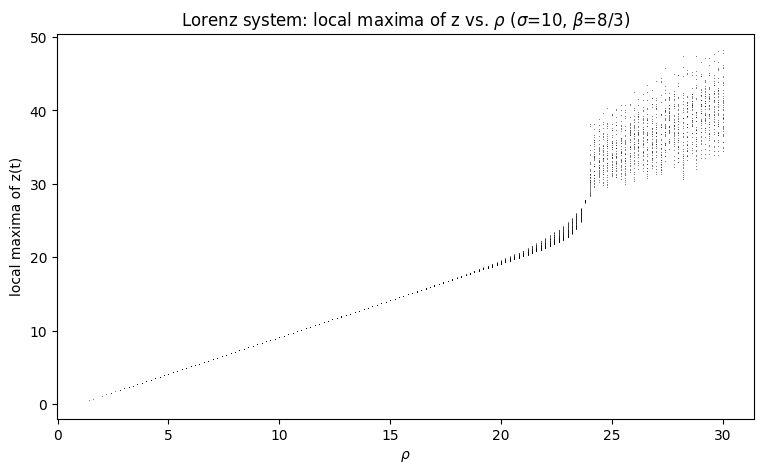

In [11]:
def local_maxima(t, z, t_min):
    mask = t >= t_min
    tt, zz = t[mask], z[mask]
    idx = np.where((zz[1:-1] > zz[:-2]) & (zz[1:-1] > zz[2:]))[0] + 1
    return zz[idx]

rho_vals = np.arange(0, 30 + 1e-9, 0.2)
sigma_fixed, beta_fixed = 10.0, 8/3
rho_plot, z_max_plot = [], []
for rho in rho_vals:
    t_s, Y_s = integrate(lorenz_rhs, [1, 1, 1], (0, 50), 0.01, args=(sigma_fixed, rho, beta_fixed))
    maxima = local_maxima(t_s, Y_s[2], t_min=20)
    rho_plot.extend([rho]*len(maxima))
    z_max_plot.extend(maxima)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rho_plot, z_max_plot, ",", color="black", alpha=0.5, markersize=0.5)
ax.set_xlabel(r"$\rho$"); ax.set_ylabel("local maxima of z(t)")
ax.set_title(r"Lorenz system: local maxima of z vs. $\rho$ ($\sigma$=10, $\beta$=8/3)")
savefig(fig, "C1_lorenz_rho_sweep.png")
plt.show()


For small ρ there’s basically nothing plotted because the system just dies down to a fixed point (no oscillation, so no local maxima to record). As ρ grows the trajectory starts spiraling toward a stable point and the maxima trace a single smooth line.Then around ρ ≈ 24.7 it suddenly turns into a scattered band instead of one line, and that’s the chaos onset, which actually matches the value I remember reading as the ”official” threshold for Lorenz. After that point the spread of maxima just gets wider and wider as ρ keeps increasing toward 30.

### C.2 Step-Size Sensitivity

Same chaotic parameters as B.2 ($\sigma=10,\rho=28,\beta=8/3$), same IC, same length $T=50$; only $dt$ varies: $0.001$ (fine), $0.01$ (baseline), $0.05$ (coarse). All three are evaluated on a common time grid so the trajectories can be compared point-by-point.

saved C2_lorenz_dt_overlay_timeseries.png


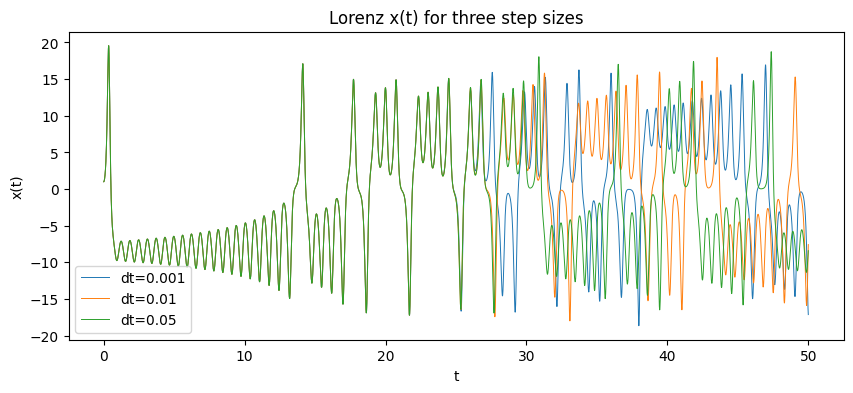

saved C2_lorenz_dt_overlay_phase3d.png


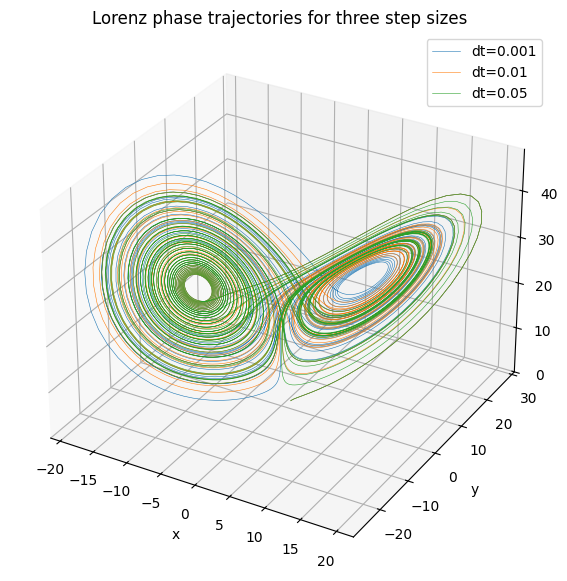

saved C2_lorenz_dt_divergence.png


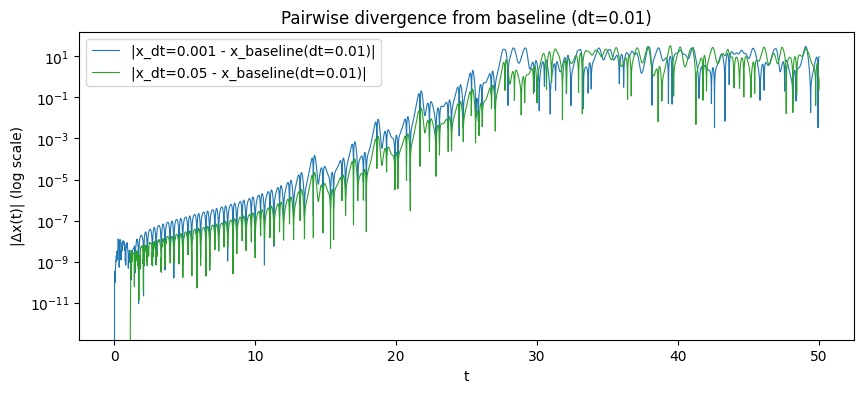

In [12]:
dts = [0.001, 0.01, 0.05]
t_common = np.arange(0, 50 + 1e-9, 0.01)
results = {}
for dt in dts:
    sol = solve_ivp(lorenz_rhs, (0, 50), [1, 1, 1], method="RK45", t_eval=t_common,
                     args=(10.0, 28.0, 8/3), max_step=dt, rtol=1e-9, atol=1e-9)
    results[dt] = sol.y

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for dt, col in zip(dts, colors):
    ax.plot(t_common, results[dt][0], lw=0.7, label=f"dt={dt}", color=col)
ax.set_xlabel("t"); ax.set_ylabel("x(t)")
ax.set_title("Lorenz x(t) for three step sizes")
ax.legend()
savefig(fig, "C2_lorenz_dt_overlay_timeseries.png")
plt.show()

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
for dt, col in zip(dts, colors):
    Y = results[dt]
    ax.plot(Y[0], Y[1], Y[2], lw=0.4, label=f"dt={dt}", color=col)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("Lorenz phase trajectories for three step sizes")
ax.legend()
savefig(fig, "C2_lorenz_dt_overlay_phase3d.png")
plt.show()

baseline = results[0.01]
fig, ax = plt.subplots(figsize=(10, 4))
for dt, col in zip(dts, colors):
    if dt == 0.01:
        continue
    diff = np.abs(results[dt][0] - baseline[0])
    ax.plot(t_common, diff, lw=0.8, label=f"|x_dt={dt} - x_baseline(dt=0.01)|", color=col)
ax.set_yscale("log")
ax.set_xlabel("t"); ax.set_ylabel("|Δx(t)| (log scale)")
ax.set_title("Pairwise divergence from baseline (dt=0.01)")
ax.legend()
savefig(fig, "C2_lorenz_dt_divergence.png")
plt.show()


For roughly the first 15–20 time units all three runs overlap almost perfectly. Then the divergence plot (log scale) grows in a straight line, meaning the gap grows exponentially, not gradually. That's sensitive dependence on initial conditions: even a tiny step-size/rounding difference gets blown up exponentially by the system. After t ≈ 27–30 the divergence flattens out, since the trajectories are now fully decorrelated and both stuck inside the same bounded attractor, so they can't get "more different." So dt = 0.01 is fine for showing the attractor's shape, but no matter how small dt is, two runs will always disagree eventually that's just how chaos works, not a numerical bug.

##Conclusion
Comparing discrete and continuous chaos, they both reach chaos through a similar looking process,the logistic/H´énon period-doubling cascade and the Lorenz ρ-sweep both show a fixed point turning into chaos step by step, but the actual mechanism is different: discrete maps create chaos in one folding step per iteration, while continuous systems stretch and fold the trajectory continuously over time, always staying inside their strange attractor. Going from chaotic to hyperchaotic (Rössler to hyperchaotic Rössler) didn’t change this basic picture much, it just added a second direction where trajectories pull apart, and that needed one more state variable to be possible. And overall, every system I simulated shared the same core idea of chaos: trajectories that never repeat but also never escape, and that are extremely sensitive to tiny differences, which I saw directly in Part C where just changing the step size was enough to make two ”identical” simulations diverge completely after some time.